In [1]:
# ================================
# Stock Price Prediction — LSTM
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported! 🚀")

Libraries imported! 🚀


In [2]:
import yfinance as yf

# Download Apple stock data — 5 years
stock = yf.download('AAPL', start='2019-01-01', end='2024-01-01')

print(stock.head())
print(f"\nShape: {stock.shape}")
print(f"\nColumns: {stock.columns.tolist()}")
print(f"\nDate range: {stock.index[0]} to {stock.index[-1]}")

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.503723  37.724587  36.627401  36.784142  148158800
2019-01-03  33.768082  34.606406  33.722959  34.193179  365248800
2019-01-04  35.209606  35.278479  34.150423  34.323786  234428400
2019-01-07  35.131241  35.344980  34.649145  35.314106  219111200
2019-01-08  35.800957  36.055068  35.271365  35.518348  164101200

Shape: (1258, 5)

Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Date range: 2019-01-02 00:00:00 to 2023-12-29 00:00:00


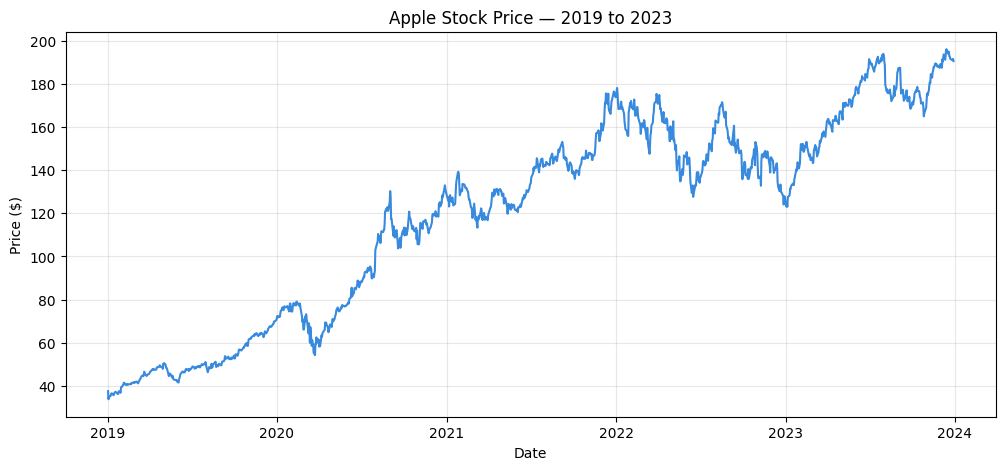

Highest price: $196.07
Lowest price:  $33.77
Average price: $120.32


In [3]:
# Plot Apple stock price
plt.figure(figsize=(12, 5))
plt.plot(stock['Close'], color='#378ADD', linewidth=1.5)
plt.title('Apple Stock Price — 2019 to 2023')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

# Basic stats
print(f"Highest price: ${stock['Close'].max().values[0]:.2f}")
print(f"Lowest price:  ${stock['Close'].min().values[0]:.2f}")
print(f"Average price: ${stock['Close'].mean().values[0]:.2f}")

In [4]:
# Use only Close price
data = stock['Close'].values.reshape(-1, 1)

# Scale data between 0 and 1
# LSTM works best with scaled data!
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print(f"Original price range: ${data.min():.2f} to ${data.max():.2f}")
print(f"Scaled range: {data_scaled.min():.2f} to {data_scaled.max():.2f}")

# Create sequences — LSTM needs sequences not single values!
# Use 60 days to predict next day
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])  # last 60 days
        y.append(data[i, 0])               # next day price
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_length=60)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst sequence — last 5 values: {X[0][-5:]}")
print(f"First target: {y[0]:.4f}")

Original price range: $33.77 to $196.07
Scaled range: 0.00 to 1.00

X shape: (1198, 60)
y shape: (1198,)

First sequence — last 5 values: [0.07269114 0.06929659 0.06643112 0.06889986 0.06926721]
First target: 0.0711


In [5]:
# Split 80/20
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training sequences: {X_train.shape[0]}")
print(f"Testing sequences: {X_test.shape[0]}")

# Reshape for LSTM — needs 3D input (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

print(f"\nX_train tensor shape: {X_train_t.shape}")
print(f"X_test tensor shape: {X_test_t.shape}")

Training sequences: 958
Testing sequences: 240

X_train tensor shape: torch.Size([958, 60, 1])
X_test tensor shape: torch.Size([240, 60, 1])


In [6]:
# Build LSTM Neural Network
class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(StockLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, 
                            num_layers, batch_first=True,
                            dropout=0.2)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))
        
        # Take last time step output
        out = self.fc(out[:, -1, :])
        return out

# Create model
model = StockLSTM()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

StockLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

Total parameters: 31051


In [7]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 50
train_losses = []

print("Training LSTM...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    y_pred = model(X_train_t).squeeze()
    loss = criterion(y_pred, y_train_t)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 → Loss: {loss.item():.6f}")

print("\nTraining complete! ✅")

Training LSTM...
Epoch 10/50 → Loss: 0.129392
Epoch 20/50 → Loss: 0.068582
Epoch 30/50 → Loss: 0.049537
Epoch 40/50 → Loss: 0.039757
Epoch 50/50 → Loss: 0.027857

Training complete! ✅


RMSE: $30.84
MAE: $29.57


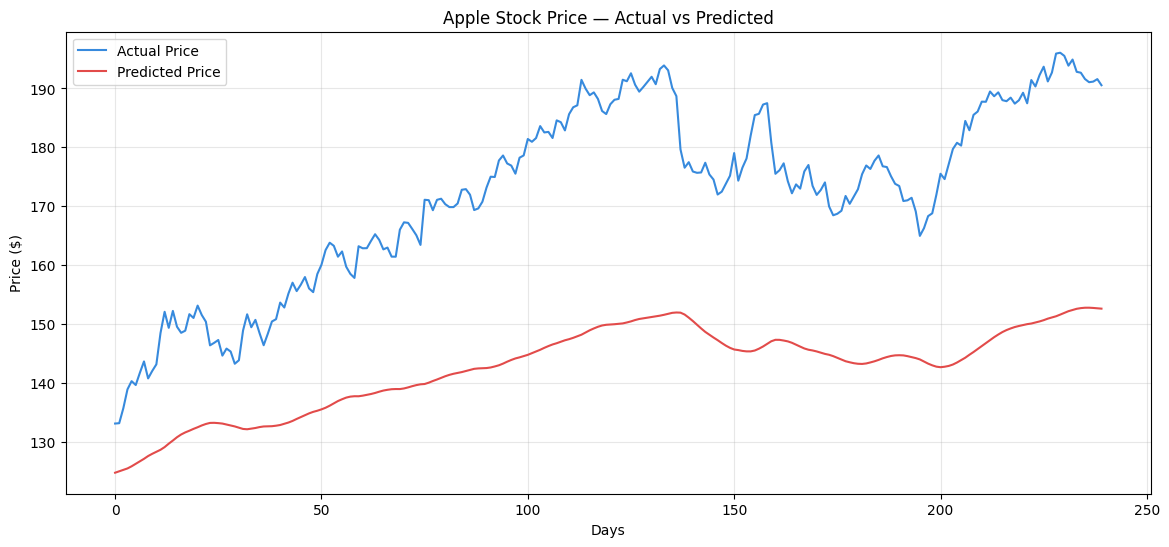

In [8]:
# Make predictions
model.eval()
with torch.no_grad():
    train_pred = model(X_train_t).squeeze().numpy()
    test_pred = model(X_test_t).squeeze().numpy()

# Inverse transform — convert back to actual prices
train_pred_actual = scaler.inverse_transform(train_pred.reshape(-1, 1))
test_pred_actual = scaler.inverse_transform(test_pred.reshape(-1, 1))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate errors
rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred_actual))
mae = mean_absolute_error(y_test_actual, test_pred_actual)
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, color='#378ADD', linewidth=1.5, label='Actual Price')
plt.plot(test_pred_actual, color='#E24B4A', linewidth=1.5, label='Predicted Price')
plt.title('Apple Stock Price — Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training more...
Epoch 20/100 → Loss: 0.005659
Epoch 40/100 → Loss: 0.002647
Epoch 60/100 → Loss: 0.002060
Epoch 80/100 → Loss: 0.001832
Epoch 100/100 → Loss: 0.001620

Improved RMSE: $9.24
Improved MAE: $7.62


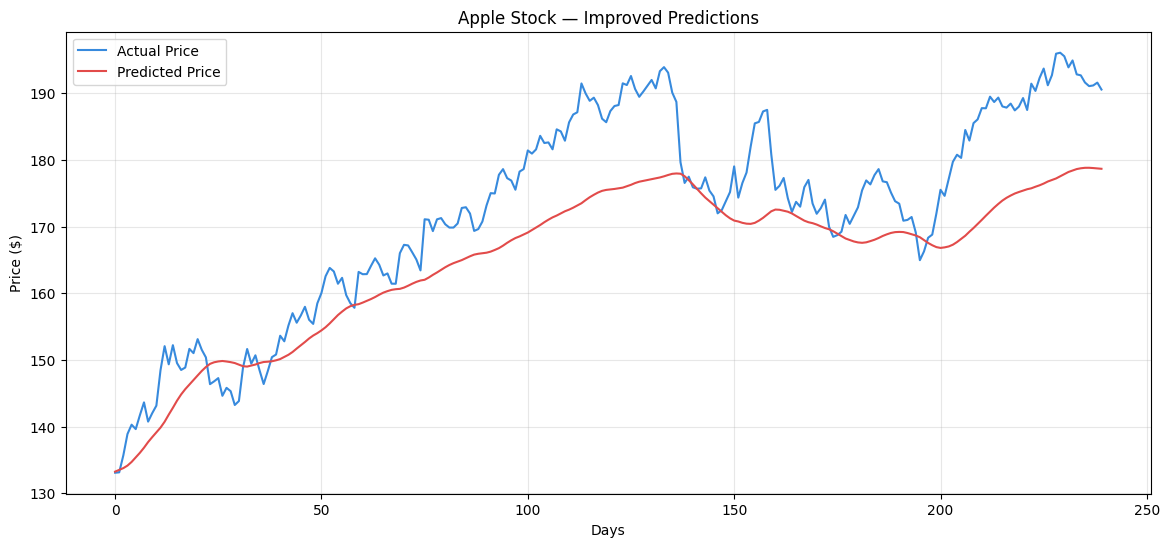

In [9]:
# Train longer with more epochs
epochs = 100
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

print("Training more...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    y_pred = model(X_train_t).squeeze()
    loss = criterion(y_pred, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 → Loss: {loss.item():.6f}")

# Evaluate again
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t).squeeze().numpy()

test_pred_actual = scaler.inverse_transform(test_pred.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred_actual))
mae = mean_absolute_error(y_test_actual, test_pred_actual)
print(f"\nImproved RMSE: ${rmse:.2f}")
print(f"Improved MAE: ${mae:.2f}")

# Plot again
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, color='#378ADD', linewidth=1.5, label='Actual Price')
plt.plot(test_pred_actual, color='#E24B4A', linewidth=1.5, label='Predicted Price')
plt.title('Apple Stock — Improved Predictions')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()